In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("datakecukupanpangan.csv")

df.head()

,No,Tahun,Kode_Provinsi,Provinsi,PoU,Jumlah_Penduduk,Penduduk_Undernourish
0,1,2018,11,ACEH,8.66,5243400,454185
1,2,2018,12,SUMATERA UTARA,5.73,14476000,829915
2,3,2018,13,SUMATERA BARAT,5.45,5411800,294684
3,4,2018,14,RIAU,9.63,6717600,646660
4,5,2018,15,JAMBI,10.04,3527100,354285


# A) Kenalan Data

##1) jumlah baris & kolom

In [ ]:
df.shape

print("Jumlah baris:", df.shape[0])
print("Jumlah kolom:", df.shape[1])

Jumlah baris: 242
Jumlah kolom: 7


##2) Daftar nama kolom

In [ ]:
print(list(df.columns))

['No', 'Tahun', 'Kode_Provinsi', 'Provinsi', 'PoU', 'Jumlah_Penduduk', 'Penduduk_Undernourish']


##3) Rentang tahun

In [ ]:
print("Tahun paling kecil:", df["Tahun"].min())
print("Tahun paling besar:", df["Tahun"].max())

Tahun paling kecil: 2018
Tahun paling besar: 2024


##4) Jumlah provinsi per tahun

2018

In [ ]:
df[df["Tahun"] == 2018]["Provinsi"].nunique() #nunique = hitung nilai yang berbeda

34

2024

In [ ]:
df[df["Tahun"] == 2024]["Provinsi"].nunique()

38

#B) Data quality check

##5) Cek missing value

In [ ]:
df.isnull().sum()

,0
No,0
Tahun,0
Kode_Provinsi,0
Provinsi,0
PoU,0
Jumlah_Penduduk,0
Penduduk_Undernourish,0


tidak ada

##6) Cek baris duplikat (Tahun + Provinsi)

In [ ]:
df.duplicated(subset=["Tahun","Provinsi"]).sum()

np.int64(0)

In [ ]:
df.duplicated().sum()

np.int64(0)

tidak ada

##7) Cek nilai tidak masuk akal

In [ ]:
df[(df["PoU"] < 0) | (df["PoU"] > 100)]

,No,Tahun,Kode_Provinsi,Provinsi,PoU,Jumlah_Penduduk,Penduduk_Undernourish


In [ ]:
len(df[(df["PoU"] < 0) | (df["PoU"] > 100)])

0

##Penduduk_Undernourish > Jumlah_Penduduk

In [ ]:
df[df["Penduduk_Undernourish"] > df["Jumlah_Penduduk"]]

,No,Tahun,Kode_Provinsi,Provinsi,PoU,Jumlah_Penduduk,Penduduk_Undernourish
204,205,2024,11,ACEH,9.10,5652120,51434292
205,206,2024,12,SUMATERA UTARA,7.54,15368583,115879116
206,207,2024,13,SUMATERA BARAT,8.88,5786360,51382877
207,208,2024,14,RIAU,10.93,7381474,80679511
208,209,2024,15,KOTA JAMBI,10.58,3739406,39562915
209,210,2024,16,SUMATERA SELATAN,8.88,5786360,51382877
210,211,2024,17,BENGKULU,9.86,2075023,20459727
211,212,2024,18,LAMPUNG,10.68,8806627,94054776
212,213,2024,19,KEPULAUAN BANGKA BELITUNG,10.66,1537917,16394195
213,214,2024,21,KEPULAUAN RIAU,9.55,2575911,24599950


In [ ]:
len(df[df["Penduduk_Undernourish"] > df["Jumlah_Penduduk"]])

38

#C) Fitur Baru + Validasi

##8) kolom Rate_Undernourish

In [ ]:
df["Rate_Undernourish"] = (df["Penduduk_Undernourish"] / df["Jumlah_Penduduk"]) * 100

df.head()

,No,Tahun,Kode_Provinsi,Provinsi,PoU,Jumlah_Penduduk,Penduduk_Undernourish,Rate_Undernourish
0,1,2018,11,ACEH,8.66,5243400,454185,8.662032
1,2,2018,12,SUMATERA UTARA,5.73,14476000,829915,5.733041
2,3,2018,13,SUMATERA BARAT,5.45,5411800,294684,5.445212
3,4,2018,14,RIAU,9.63,6717600,646660,9.626355
4,5,2018,15,JAMBI,10.04,3527100,354285,10.044654


##9) Bandingkan Rate_Undernourish dengan PoU

In [ ]:
#Hitung selisih
df["Selisih"] = df["Rate_Undernourish"] - df["PoU"]

In [ ]:
#Selisih absolut
df["Selisih_abs"] = df["Selisih"].abs()

In [ ]:
#Top 5 selisih terbesar
df.nlargest(5, "Selisih_abs")[["Tahun","Provinsi","PoU","Rate_Undernourish","Selisih"]]

,Tahun,Provinsi,PoU,Rate_Undernourish,Selisih
239,2024,PAPUA TENGAH,37.69,3768.999989,3731.309989
234,2024,MALUKU,31.66,3166.000018,3134.340018
238,2024,PAPUA SELATAN,29.26,2926.000083,2896.740083
235,2024,MALUKU UTARA,28.44,2844.000009,2815.560009
240,2024,PAPUA PEGUNUNGAN,27.26,2726.000031,2698.740031


tidak mirip

#D) Analisis Ringkas

##10) Tahun terbaru

In [ ]:
tahun_terbaru = df["Tahun"].max()
tahun_terbaru

2024

In [ ]:
df_latest = df[df["Tahun"] == tahun_terbaru]

In [ ]:
#Top 5 PoU tertinggi
df_latest.nlargest(5, "PoU")[["Provinsi","PoU"]]

,Provinsi,PoU
239,PAPUA TENGAH,37.69
234,MALUKU,31.66
238,PAPUA SELATAN,29.26
235,MALUKU UTARA,28.44
240,PAPUA PEGUNUNGAN,27.26


In [ ]:
#Top 5 PoU terendah
df_latest.nsmallest(5, "PoU")[["Provinsi","PoU"]]

,Provinsi,PoU
219,BANTEN,2.55
221,NUSA TENGGARA BARAT,2.74
220,BALI,3.20
214,DKI JAKARTA,3.53
225,KALIMANTAN SELATAN,3.83


##11) Rata-rata PoU per tahun

In [ ]:
avg_pou = df.groupby("Tahun")["PoU"].mean()

avg_pou

,PoU
Tahun,
2018,10.696765
2019,10.306176
2020,11.017941
2021,11.324412
2022,13.676765
2023,11.488235
2024,12.640789


In [ ]:
sm_pu = df.groupby("Tahun")["Penduduk_Undernourish"].sum()

sm_pu

,Penduduk_Undernourish
Tahun,
2018,20710368
2019,20394363
2020,22135516
2021,23826870
2022,28673668
2023,24151921
2024,2264714915


#E) Visualisasi

##12) Line Chart rata-rata PoU per tahun

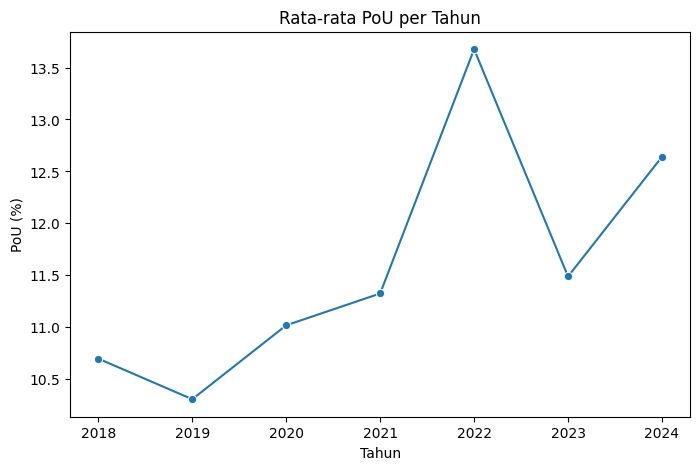

In [ ]:
plt.figure(figsize=(8,5))

sns.lineplot(data=avg_pou, x="Tahun", y="PoU", marker="o")

plt.title("Rata-rata PoU per Tahun")
plt.xlabel("Tahun")
plt.ylabel("PoU (%)")

plt.show()

In [ ]:
top10 = df_latest.nlargest(10, "PoU")

#13) Bar Chart Top 10 PoU tertinggi tahun terbaru

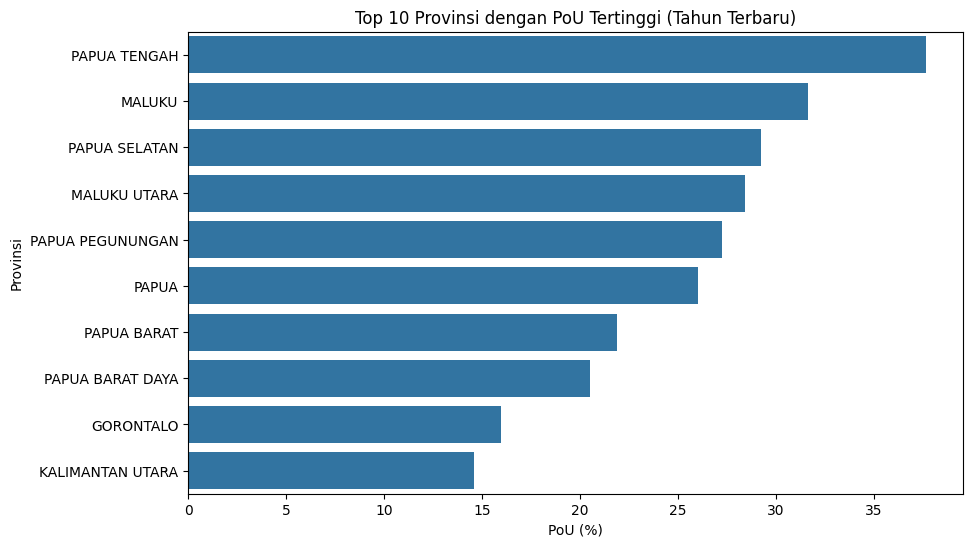

In [ ]:
plt.figure(figsize=(10,6))

sns.barplot(data=top10, x="PoU", y="Provinsi")

plt.title("Top 10 Provinsi dengan PoU Tertinggi (Tahun Terbaru)")
plt.xlabel("PoU (%)")
plt.ylabel("Provinsi")

plt.show()

##14) insight

Rata-rata PoU mengalami kenaikan pada beberapa tahun terakhir,
yang menunjukkan adanya peningkatan risiko kekurangan gizi.

Provinsi dengan PoU tertinggi berada di wilayah Indonesia Timur,
seperti Papua Tengah dan Maluku.

Rate_Undernourish yang dihitung dari data populasi memiliki
selisih besar dibanding PoU, kemungkinan karena perbedaan
satuan pada data Penduduk_Undernourish.